<a href="https://colab.research.google.com/github/syiffac/Machine-Learning-Project_Email-Phising-Detection/blob/main/Project_ML_Email_Spam_Detection_Aisyah_Syifa_H1D023043.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#visual
sns.set_style("whitegrid")

#import dataset
ceas = pd.read_csv("CEAS_08.csv")
enron = pd.read_csv("Enron.csv")
ling = pd.read_csv("Ling.csv")
nazario = pd.read_csv("Nazario.csv")
nigerian = pd.read_csv("Nigerian_Fraud.csv")
spam = pd.read_csv("SpamAssasin.csv")

In [ ]:
#cek struktur kolom
print("CEAS")
print(ceas.columns)

print("\nEnron")
print(enron.columns)

print("\nLing")
print(ling.columns)

print("\nNazario")
print(nazario.columns)

print("\nNigerian")
print(nigerian.columns)

print("\nSpamAssassin")
print(spam.columns)

CEAS
Index(['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls'], dtype='object')

Enron
Index(['subject', 'body', 'label'], dtype='object')

Ling
Index(['subject', 'body', 'label'], dtype='object')

Nazario
Index(['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label'], dtype='object')

Nigerian
Index(['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label'], dtype='object')

SpamAssassin
Index(['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls'], dtype='object')


In [ ]:
#merapikan nama kolom
datasets = [ceas, enron, ling, nazario, nigerian, spam]

for df in datasets:
    df.columns = df.columns.str.lower()

In [ ]:
#samakan struktur kolom
standard_columns = [
    "sender",
    "receiver",
    "date",
    "subject",
    "body",
    "urls",
    "label"
]

#tambahkan kolom yang belum ada
for df in datasets:

    for col in standard_columns:

        if col not in df.columns:
            df[col] = np.nan

    # urutkan kolom
    df = df[standard_columns]

In [ ]:
#reassign dataset
processed_datasets = []

for df in datasets:

    for col in standard_columns:

        if col not in df.columns:
            df[col] = np.nan

    df = df[standard_columns]

    processed_datasets.append(df)

In [ ]:
#merge dataset
df = pd.concat(
    processed_datasets,
    ignore_index=True
)

#cek dataset final (shape dataset)
print(df.shape)

print(df.columns) #cek nama kolom

df.head() #cek sample data

(82486, 7)
Index(['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label'], dtype='object')


,sender,receiver,date,subject,body,urls,label
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1.0,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1.0,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1.0,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,1.0,0
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1.0,1


In [ ]:
#cek informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sender    49529 non-null  object 
 1   receiver  47768 non-null  object 
 2   date      49377 non-null  object 
 3   subject   82139 non-null  object 
 4   body      82485 non-null  object 
 5   urls      49860 non-null  float64
 6   label     82486 non-null  int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 4.4+ MB


label
1    42891
0    39595
Name: count, dtype: int64
label
1    51.997915
0    48.002085
Name: proportion, dtype: float64


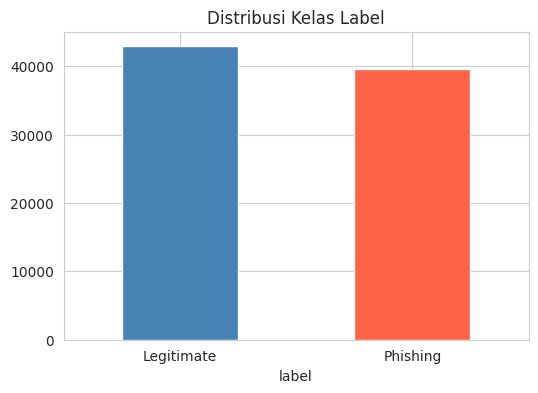

In [ ]:
#cek distribusi label
print(df["label"].value_counts()) #hitung jumlah label
print(df["label"].value_counts(normalize=True) * 100) #persentase label
plt.figure(figsize=(6,4))

df["label"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"]
)

plt.title("Distribusi Kelas Label")

plt.xticks(
    [0,1],
    ["Legitimate", "Phishing"],
    rotation=0
)

plt.show() #visualisasi

In [ ]:
#save dataset final
df.to_csv("merged_phishing_dataset.csv", index=False)

sender      32957
receiver    34718
date        33109
subject       347
body            1
urls        32626
label           0
dtype: int64
sender      39.954659
receiver    42.089567
date        40.138933
subject      0.420677
body         0.001212
urls        39.553379
label        0.000000
dtype: float64


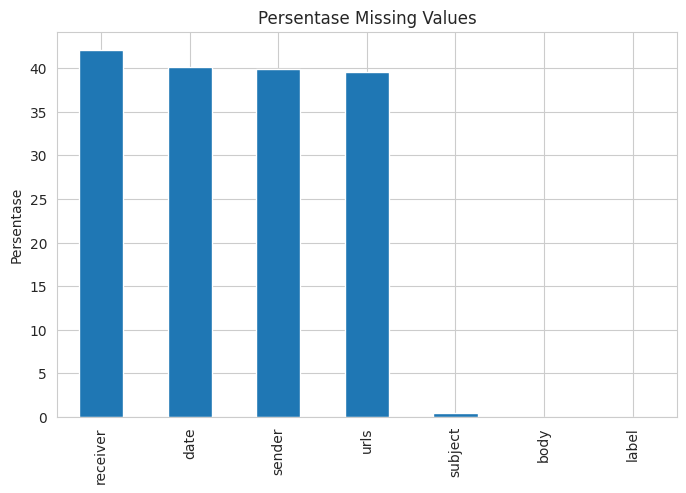

In [ ]:
#cek missing values
missing = df.isnull().sum()

print(missing)

#persentase missing values
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent)

#visualisasi
missing_percent.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Persentase Missing Values")
plt.ylabel("Persentase")

plt.show()

In [ ]:
#cek duplikat data

# Create 'text_combined' column
df['text_combined'] = df['subject'].fillna('') + ' ' + df['body'].fillna('')

print(df.duplicated().sum()) #jumlah duplikat

#cek duplikat by text_combined
duplicates = df.duplicated(
    subset=["text_combined"]
).sum()

print(duplicates)

0
0


count    8.248600e+04
mean     1.760422e+03
std      1.693771e+04
min      0.000000e+00
25%      3.100000e+02
50%      7.350000e+02
75%      1.916000e+03
max      4.599644e+06
Name: body_len, dtype: float64


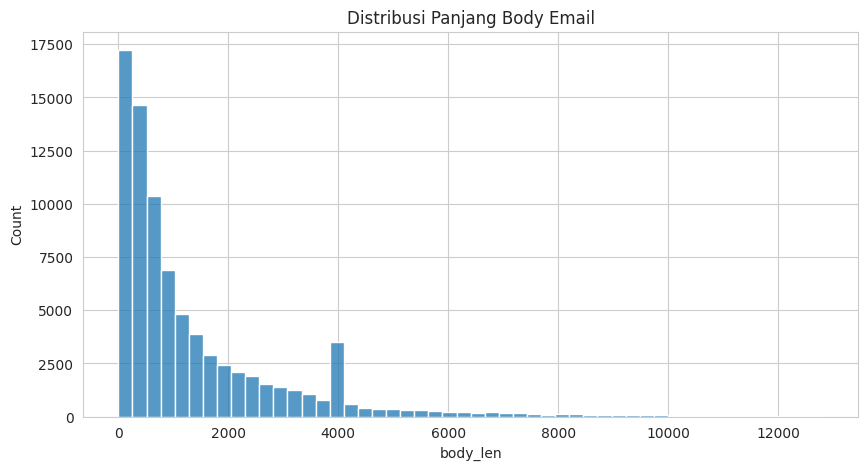

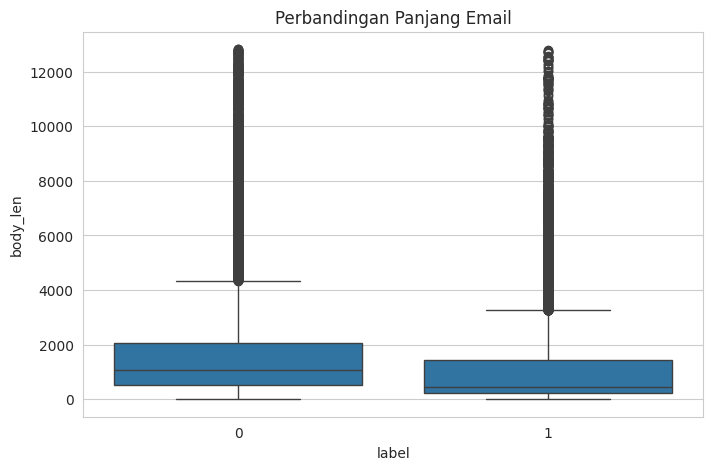

In [ ]:
#analisis panjang teks
df["body_len"] = (
    df["body"]
    .fillna("")
    .apply(len)
) #buat fitur panjang body

print(df["body_len"].describe()) #statistik

#histogram
q99 = df["body_len"].quantile(0.99)

filtered = df[df["body_len"] <= q99]

plt.figure(figsize=(10,5))

sns.histplot(
    filtered["body_len"],
    bins=50
)

plt.title("Distribusi Panjang Body Email")

plt.show()

#compare per label (boxplot)
plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="body_len",
    data=filtered
)

plt.title("Perbandingan Panjang Email")

plt.show()

count    82486.000000
mean        36.166719
std         34.296325
min          0.000000
25%         21.000000
50%         32.000000
75%         47.000000
max       7170.000000
Name: subject_len, dtype: float64


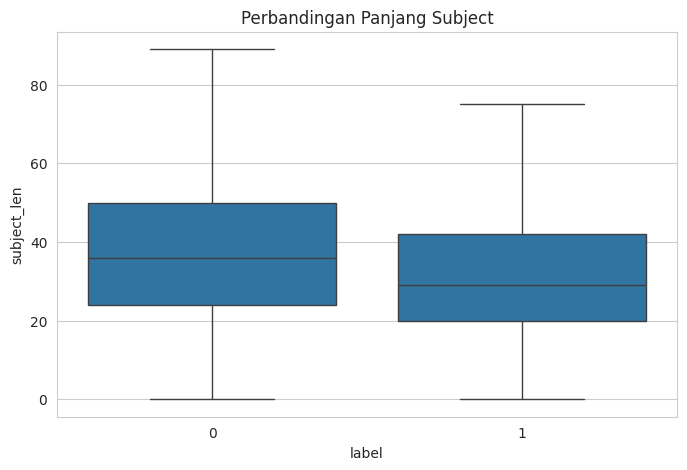

In [ ]:
#analisis panjang subject email
df["subject_len"] = (
    df["subject"]
    .fillna("")
    .apply(len)
)

print(df["subject_len"].describe())


filtered_for_subject = df[df["body_len"] <= q99]

plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="subject_len",
    data=filtered_for_subject,
    showfliers=False
)

plt.title("Perbandingan Panjang Subject")

plt.show()